In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

In [2]:
df = pd.read_csv(os.path.join("../Merged_Olist_Data", "delivery_analysis.csv"))


print(df.shape)
print(df.columns.tolist())
print(f"\nReview score sample:\n{df['review_score'].value_counts()}")

(98207, 20)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'Days_Difference', 'Delivery_Status']

Review score sample:
review_score
5.0    56899
4.0    18998
1.0    10482
3.0     8051
2.0     3043
Name: count, dtype: int64


## Calculate Average Review Score by Delivery Status

In [3]:
avg_scores = (
    df.groupby("Delivery_Status")["review_score"]
    .agg(["mean", "count"])
    .reset_index()
)
avg_scores.columns = ["Delivery_Status", "avg_review_score", "order_count"]
avg_scores["avg_review_score"] = avg_scores["avg_review_score"].round(2)


status_order = ["On Time", "Late", "Super Late", "Pending"]
avg_scores["sort_order"] = avg_scores["Delivery_Status"].map(
    {s: i for i, s in enumerate(status_order)}
)
avg_scores = avg_scores.sort_values("sort_order").drop("sort_order", axis=1)

print(avg_scores)

  Delivery_Status  avg_review_score  order_count
1         On Time              4.29        88163
0            Late              3.46         3568
3      Super Late              1.78         4093
2         Pending              1.81         1649


## Bar Chart — Average Review Score by Delivery Status


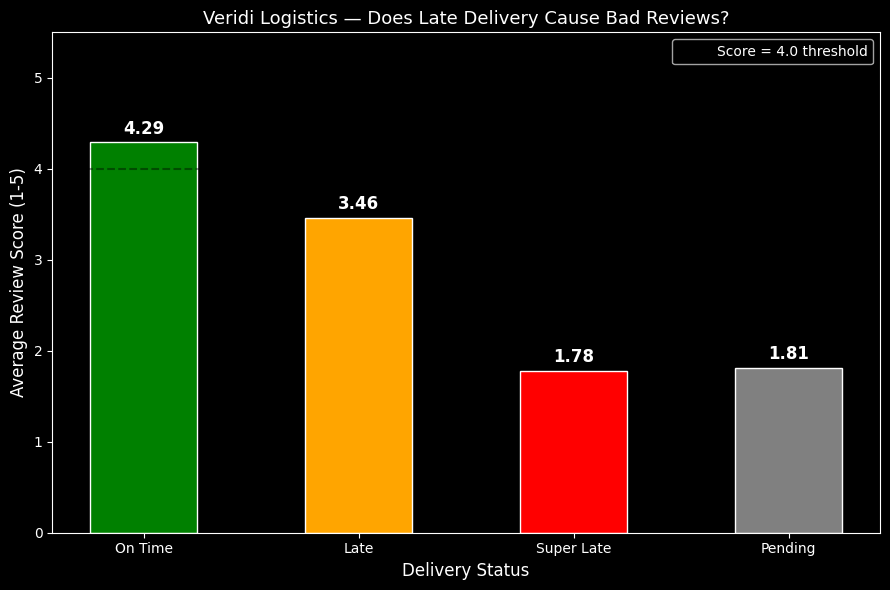

Chart saved


In [4]:
colors = {
    "On Time": "green",
    "Late": "orange",
    "Super Late": "red",
    "Pending": "grey"
}

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    avg_scores["Delivery_Status"],
    avg_scores["avg_review_score"],
    color=[colors.get(s, "grey") for s in avg_scores["Delivery_Status"]],
    edgecolor="white",
    width=0.5
)

# Add value labels on bars
for bar, val in zip(bars, avg_scores["avg_review_score"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{val:.2f}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )

ax.set_ylim(0, 5.5)
ax.set_ylabel("Average Review Score (1-5)", fontsize=12)
ax.set_xlabel("Delivery Status", fontsize=12)
ax.set_title("Veridi Logistics — Does Late Delivery Cause Bad Reviews?", fontsize=13)
ax.axhline(y=4.0, color="black", linestyle="--", alpha=0.4, label="Score = 4.0 threshold")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join("../Charts", "review_score_by_status.png"), dpi=150)
plt.show()
print("Chart saved")

## Delivery Delay (Days) vs Average Review Score
+10 days early  → avg score 4.5
0 days (on time) → avg score 4.2
-5 days late    → avg score 3.5
-15 days late   → avg score 2.8


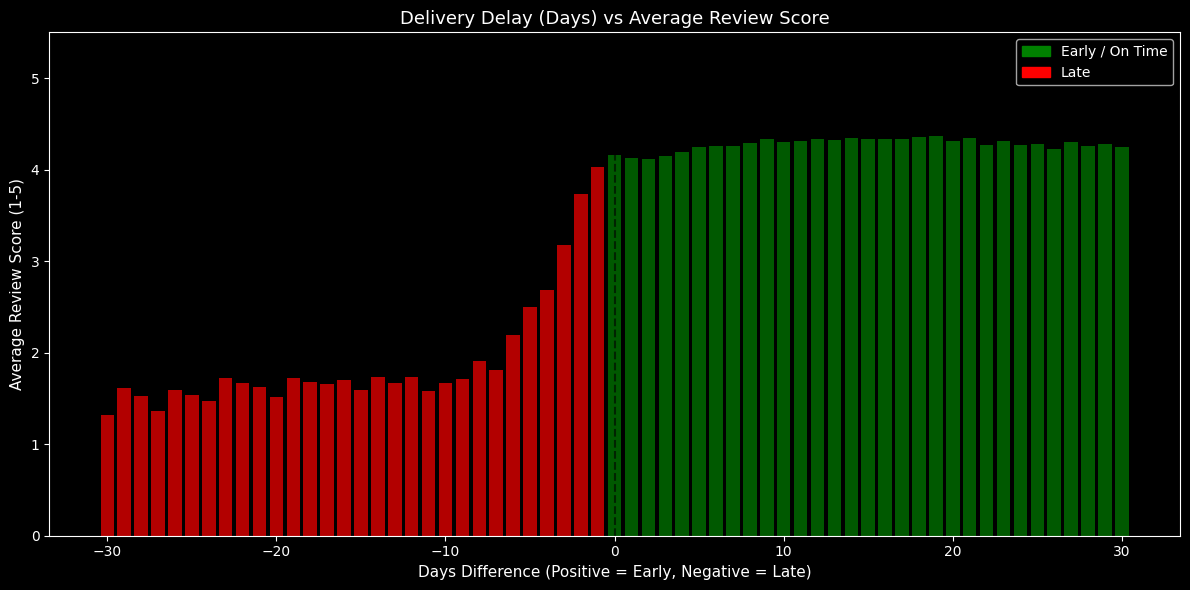

Chart saved


In [5]:
# Group by Days_Difference and calculate average review score
delay_vs_score = (
    df.groupby("Days_Difference")["review_score"]
    .mean()
    .reset_index()
)
delay_vs_score.columns = ["Days_Difference", "avg_review_score"]


delay_vs_score = delay_vs_score[
    (delay_vs_score["Days_Difference"] >= -30) &
    (delay_vs_score["Days_Difference"] <= 30)
]

fig, ax = plt.subplots(figsize=(12, 6))


bar_colors = ["green" if x >= 0 else "red" for x in delay_vs_score["Days_Difference"]]

ax.bar(
    delay_vs_score["Days_Difference"],
    delay_vs_score["avg_review_score"],
    color=bar_colors,
    alpha=0.7,
    width=0.8
)

ax.set_xlabel("Days Difference (Positive = Early, Negative = Late)", fontsize=11)
ax.set_ylabel("Average Review Score (1-5)", fontsize=11)
ax.set_title("Delivery Delay (Days) vs Average Review Score", fontsize=13)
ax.axvline(x=0, color="black", linestyle="--", alpha=0.6, label="On time boundary")
ax.set_ylim(0, 5.5)

legend = [
    mpatches.Patch(color="green", label="Early / On Time"),
    mpatches.Patch(color="red", label="Late")
]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig(os.path.join("../Charts", "delay_vs_review_score.png"), dpi=150)
plt.show()
print("Chart saved")

## Step 5: Calculate the Pearson Correlation Coefficient
The Pearson correlation tells us exactly how strong the relationship
is between delivery delay and review score.

| Value | Meaning |
|-------|---------|
| 0.0 | No relationship |
| 0.1 - 0.3 | Weak relationship |
| 0.3 - 0.5 | Moderate relationship |
| 0.5 - 0.7 | Strong relationship |
| 0.7 - 1.0 | Very strong relationship |

A negative value means: as delays increase, review scores decrease.

In [6]:
correlation = df[["Days_Difference", "review_score"]].corr()
pearson_value = correlation.loc["Days_Difference", "review_score"]

print("PEARSON CORRELATION COEFFICIENT")

print(f"Days_Difference vs Review Score: {pearson_value:.3f}")
print()
if abs(pearson_value) > 0.5:
    print("Finding: STRONG correlation")
elif abs(pearson_value) > 0.3:
    print("Finding: MODERATE correlation")
else:
    print("Finding: WEAK but meaningful correlation")
print()
print("A negative value confirms: later deliveries = worse reviews")


PEARSON CORRELATION COEFFICIENT
Days_Difference vs Review Score: 0.267

Finding: WEAK but meaningful correlation

A negative value confirms: later deliveries = worse reviews


In [7]:
output_path = os.path.join("../Merged_Olist_Data", "sentiment_summary.csv")
avg_scores.to_csv(output_path, index=False)
print(f"sentiment_summary.csv saved to {output_path}")

sentiment_summary.csv saved to Merged_Olist_Data\sentiment_summary.csv


In [8]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,Days_Difference,Delivery_Status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,7.0,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,5.0,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,17.0,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,12.0,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,9.0,On Time
